In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import pickle

In [2]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')
df.head()
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [3]:
# Preprocess the dataset
# Drop irrelevant columns
df.columns = df.columns.str.strip()
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Encode categorical variables
label_encoder_gender = LabelEncoder()
df['Gender'] = label_encoder_gender.fit_transform(df['Gender'] )
df


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [5]:
# One hot encode the 'Geography' column
df.head()
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder_geo = OneHotEncoder(sparse_output=False)
geo_encoded = one_hot_encoder_geo.fit_transform(df[['Geography']])

print(geo_encoded)
df

[[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [6]:
one_hot_encoder_geo.get_feature_names_out(['Geography'])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=one_hot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoded_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [7]:
 # Concatenate the new columns with the original dataframe
df = pd.concat([df.drop('Geography',axis=1), geo_encoded_df], axis=1)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [8]:
# save encoders and scaler
with open('label_encoder_gender.pkl', 'wb') as file:
    pickle.dump(label_encoder_gender, file)

with open('one_hot_encoder_geo.pkl', 'wb') as file:
    pickle.dump(one_hot_encoder_geo, file)


In [9]:
data = df
# Split the dataset into dependent(target) and independent(features) variables
x = data.drop(['Exited'], axis=1)
y = data['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)





 Bu kod, bir veri kümesini bağımlı (hedef) ve bağımsız (özellik) değişkenlere ayırır, ardından veri kümesini eğitim ve test setlerine böler ve özellikleri ölçekler. İşte adım adım açıklaması:

1. Bağımlı ve Bağımsız Değişkenlerin Ayrılması
data.drop(['Exited'], axis=1):
Veri kümesinden Exited sütununu çıkarır ve kalan sütunları bağımsız değişkenler (x) olarak alır.
axis=1 sütun üzerinde işlem yapıldığını belirtir.
data['Exited']:
Exited sütununu bağımlı değişken (hedef) olarak alır. Bu sütun, müşterinin ayrılıp ayrılmadığını (churn) temsil eder.
2. Veri Kümesini Eğitim ve Test Setlerine Bölme
train_test_split:
Veri kümesini eğitim ve test setlerine böler.
test_size=0.2:
Verinin %20'si test seti, %80'i eğitim seti olarak ayrılır.
random_state=42:
Rastgelelik kontrolü için bir sabit belirler. Aynı kod tekrar çalıştırıldığında aynı bölünmeyi sağlar.
x_train ve x_test:
Bağımsız değişkenlerin eğitim ve test setleri.
y_train ve y_test:
Bağımlı değişkenlerin (hedef) eğitim ve test setleri.
3. Özelliklerin Ölçeklenmesi
StandardScaler:
Özellikleri standartlaştırır (ortalama = 0, standart sapma = 1). Bu, özellikle yapay sinir ağları gibi algoritmalar için önemlidir.
scaler.fit_transform(x_train):
Eğitim setindeki özelliklerin ortalamasını ve standart sapmasını hesaplar (fit) ve bu değerleri kullanarak veriyi ölçekler (transform).
scaler.transform(x_test):
Test setini, eğitim setinden hesaplanan ortalama ve standart sapma değerlerini kullanarak ölçekler. Bu, veri sızıntısını önlemek için önemlidir.
Neden Bu İşlemler Yapılır?
Bağımlı ve Bağımsız Değişkenlerin Ayrılması:
Modelin bağımsız değişkenler (girdiler) ile bağımlı değişken (çıktı) arasındaki ilişkiyi öğrenmesi için gereklidir.
Veri Kümesini Bölme:
Modelin performansını değerlendirmek için eğitim ve test setlerine ihtiyaç vardır.
Özelliklerin Ölçeklenmesi:
Özelliklerin farklı ölçeklerde olması, modelin öğrenme sürecini zorlaştırabilir. Ölçekleme, bu sorunu çözer.

Neden Bu İşlemler Yapılır?
Bağımlı ve Bağımsız Değişkenlerin Ayrılması:
Modelin bağımsız değişkenler (girdiler) ile bağımlı değişken (çıktı) arasındaki ilişkiyi öğrenmesi için gereklidir.
Veri Kümesini Bölme:
Modelin performansını değerlendirmek için eğitim ve test setlerine ihtiyaç vardır.
Özelliklerin Ölçeklenmesi:
Özelliklerin farklı ölçeklerde olması, modelin öğrenme sürecini zorlaştırabilir. Ölçekleme, bu sorunu çözer.

Test verisi üzerinde fit işlemi yapılmaz çünkü test verisi, modelin performansını değerlendirmek için kullanılır. Eğer test verisi üzerinde fit işlemi yapılırsa, model test verisinden bilgi sızdırmış olur ve bu, modelin gerçek performansını yanlış bir şekilde yüksek gösterebilir.


In [10]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime
x_train.shape


(8000, 12)

In [12]:
# Build ann model
model = Sequential()
model.add(Input(shape=(x_train.shape[1],))) # input layer
model.add(Dense(64, activation='relu')) # hidden layer
model.add(Dense(32, activation='relu')) # hidden layer
model.add(Dense(1, activation='sigmoid')) # output layer

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
model.summary()





Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Set up early stopping and tensorboard
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train the model
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[tensorboard_callback, early_stopping])

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7602 - loss: 0.5282 - val_accuracy: 0.8338 - val_loss: 0.4051
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8323 - loss: 0.4011 - val_accuracy: 0.8481 - val_loss: 0.3724
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8517 - loss: 0.3647 - val_accuracy: 0.8537 - val_loss: 0.3593
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8643 - loss: 0.3421 - val_accuracy: 0.8481 - val_loss: 0.3542
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.3446 - val_accuracy: 0.8556 - val_loss: 0.3515
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8490 - loss: 0.3469 - val_accuracy: 0.8562 - val_loss: 0.3484
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8534 - loss: 0.3423 - val_accuracy: 0.8587 - val_loss: 0.3461
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3239 - val_accu

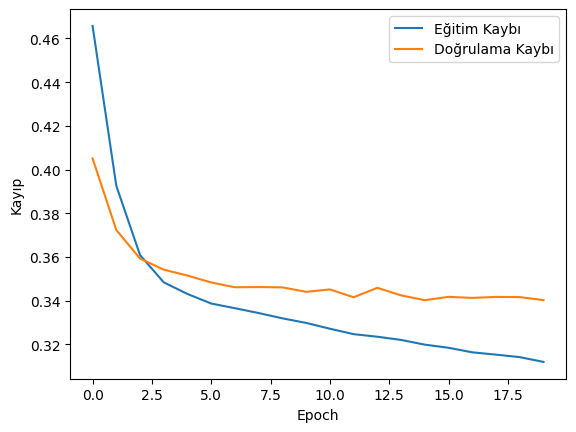

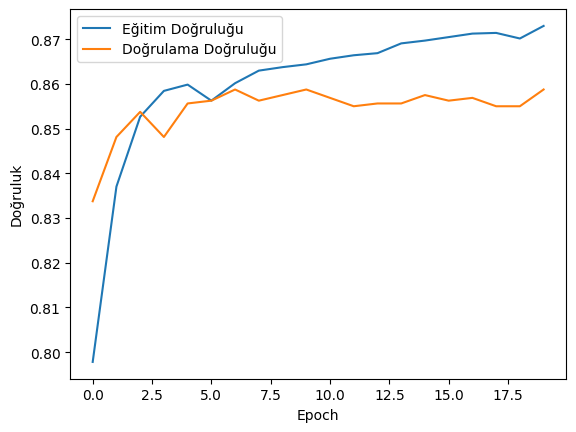

In [14]:
import matplotlib.pyplot as plt

# Eğitim ve doğrulama kaybını görselleştir
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.show()

# Eğitim ve doğrulama doğruluğunu görselleştir
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

In [15]:
model.save('model.h5')

Bu kod, eğitilmiş yapay sinir ağı modelinizi bir dosyaya kaydetmek için kullanılır. Keras'ın sağladığı bu fonksiyon, modelin yapısını, ağırlıklarını ve eğitim sırasında öğrenilen parametrelerini bir dosyada saklar. Bu sayede, modeli daha sonra yeniden yükleyip kullanabilirsiniz.
Ne İşe Yarar?
Modeli Kaydetmek:

Eğitilmiş modeli bir dosyaya kaydederek, eğitimi tekrar yapmadan doğrudan kullanabilirsiniz.
Bu, özellikle büyük veri kümelerinde uzun süren eğitim süreçlerini tekrar etmek istemediğinizde faydalıdır.
Modeli Yeniden Kullanmak:

Kaydedilen modeli daha sonra başka bir projede veya ortamda yükleyip tahmin yapmak için kullanabilirsiniz.
Üretim Ortamına Dağıtım:

Modeli kaydederek, üretim ortamına dağıtabilir ve gerçek zamanlı tahminler yapmak için kullanabilirsiniz

val_loss düşükse iyidir: Modelin doğrulama veri kümesi üzerindeki hatasının düşük olduğunu gösterir.
val_loss ve loss yakın olmalıdır: Büyük bir fark varsa, model aşırı öğrenme yapıyor olabilir.
val_loss ve val_accuracy birlikte değerlendirilmelidir: Düşük val_loss ve yüksek val_accuracy, modelin iyi performans gösterdiğini gösterir.
Görselleştirme: Eğitim sürecini görselleştirerek modelin performansını daha iyi anlayabilirsiniz.
Eğer val_loss düşmeye devam ediyorsa ve val_accuracy artıyorsa, modeliniz iyi bir şekilde öğreniyor demektir. 

In [71]:
# Load tensorboard extension
%load_ext tensorboard
%tensorboard --logdir logs/fit


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 10952), started 0:01:45 ago. (Use '!kill 10952' to kill it.)